I am using MNIST dataset and try to apply pca and compare the results before and after pca

In [6]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


In [2]:
#Load the dataset
print("Downloading that dataset it might take 30 secs.")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

In [5]:
mnist.data.shape

(70000, 784)

In [8]:
X=mnist.data
y=mnist.target

In [9]:
# We use the standard MNIST split: 60,000 for training, 10,000 for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

In [10]:
# Scale the data mandatory for pca
print("\nScaling 60k rows of data: ..")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Scaling 60k rows of data: ..


# Round1: Training random forest on raw 784-Dimensional Data...

this will take few minutes. Fire up that cpu..

In [15]:
rf_raw = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time_raw = time.time()
rf_raw.fit(X_train_scaled, y_train)
end_time_raw = time.time()
raw_duration = end_time_raw - start_time_raw

y_pred_raw = rf_raw.predict(X_test_scaled)
raw_acc = accuracy_score(y_test, y_pred_raw)

print(f"-> Raw Training Finished in {raw_duration:.2f} seconds!")
print(f" Accuract is : {raw_acc}")

-> Raw Training Finished in 81.13 seconds!
 Accuract is : 0.9675


# Round2: Compressing data with PCA and targetting 95% variance...

In [17]:
# let pca automatically calculate how many columns it needs to hit 95%
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

cols_kept = pca.n_components_
cols_destroyed = 784 - cols_kept

print(f"pca remove unnecessary: {cols_destroyed} columns.")
print(f"training random forest on the remaining: {cols_kept} compressed columns: ")

pca remove unnecessary: 774 columns.
training random forest on the remaining: 10 compressed columns: 


In [18]:
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time_pca = time.time()
rf_pca.fit(X_train_pca, y_train)
end_time_pca = time.time()
pca_duration = end_time_pca - start_time_pca

y_pred_pca = rf_pca.predict(X_test_pca)
pca_acc = accuracy_score(y_test, y_pred_pca)

print(f"-> PCA Training Finished in {pca_duration:.2f} seconds!")
print(f"accurary of pca is : {pca_acc}")

-> PCA Training Finished in 42.43 seconds!
accurary of pca is : 0.9045


## Round 3: Training Logistic Regression on Raw vs. PCA-transformed Data

Let's try a different, simpler algorithm like Logistic Regression to see if the training time dynamics change with PCA.

In [19]:
from sklearn.linear_model import LogisticRegression

print("\nTraining Logistic Regression on raw scaled data...")
lr_raw = LogisticRegression(solver='saga', tol=0.1, random_state=42, n_jobs=-1) # Use 'saga' for multiclass and L1/L2 penalties

start_time_lr_raw = time.time()
lr_raw.fit(X_train_scaled, y_train)
end_time_lr_raw = time.time()
lr_raw_duration = end_time_lr_raw - start_time_lr_raw

y_pred_lr_raw = lr_raw.predict(X_test_scaled)
lr_raw_acc = accuracy_score(y_test, y_pred_lr_raw)

print(f"-> Logistic Regression (Raw) Training Finished in {lr_raw_duration:.2f} seconds!")
print(f"   Accuracy is : {lr_raw_acc:.4f}")


Training Logistic Regression on raw scaled data...
-> Logistic Regression (Raw) Training Finished in 16.57 seconds!
   Accuracy is : 0.8847


In [20]:
print("\nTraining Logistic Regression on PCA-transformed data...")
lr_pca = LogisticRegression(solver='saga', tol=0.1, random_state=42, n_jobs=-1)

start_time_lr_pca = time.time()
lr_pca.fit(X_train_pca, y_train)
end_time_lr_pca = time.time()
lr_pca_duration = end_time_lr_pca - start_time_lr_pca

y_pred_lr_pca = lr_pca.predict(X_test_pca)
lr_pca_acc = accuracy_score(y_test, y_pred_lr_pca)

print(f"-> Logistic Regression (PCA) Training Finished in {lr_pca_duration:.2f} seconds!")
print(f"   Accuracy is : {lr_pca_acc:.4f}")


Training Logistic Regression on PCA-transformed data...
-> Logistic Regression (PCA) Training Finished in 0.43 seconds!
   Accuracy is : 0.7948


## Summary of Results with Random Forest and Logistic Regression

Let's compare all the results side-by-side.


--- Random Forest Results ---
Raw Data: Duration = 81.13s, Accuracy = 0.9675
PCA Data: Duration = 42.43s, Accuracy = 0.9045

--- Logistic Regression Results ---
Raw Data: Duration = 16.57s, Accuracy = 0.8847
PCA Data: Duration = 0.43s, Accuracy = 0.7948


/tmp/ipykernel_1510/463146726.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=durations, ax=axes[0], palette='viridis')
/tmp/ipykernel_1510/463146726.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=accuracies, ax=axes[1], palette='magma')


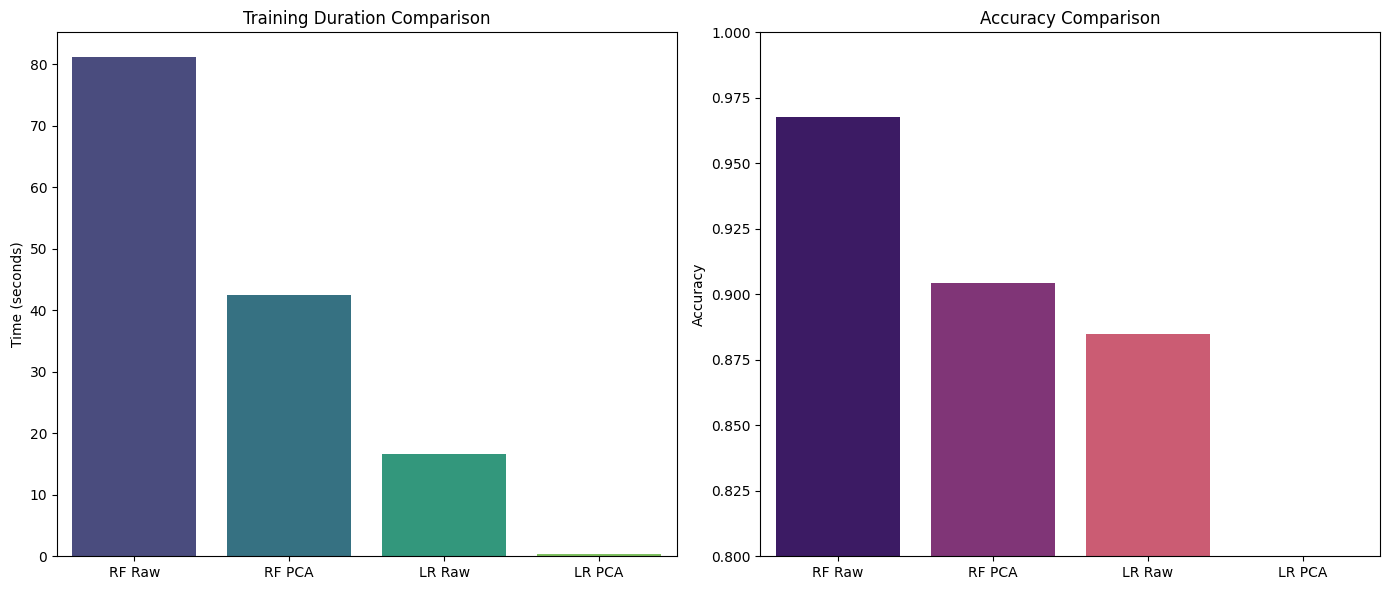

In [21]:
print("\n--- Random Forest Results ---")
print(f"Raw Data: Duration = {raw_duration:.2f}s, Accuracy = {raw_acc:.4f}")
print(f"PCA Data: Duration = {pca_duration:.2f}s, Accuracy = {pca_acc:.4f}")

print("\n--- Logistic Regression Results ---")
print(f"Raw Data: Duration = {lr_raw_duration:.2f}s, Accuracy = {lr_raw_acc:.4f}")
print(f"PCA Data: Duration = {lr_pca_duration:.2f}s, Accuracy = {lr_pca_acc:.4f}")


# Visualize the comparison
labels = ['RF Raw', 'RF PCA', 'LR Raw', 'LR PCA']
durations = [raw_duration, pca_duration, lr_raw_duration, lr_pca_duration]
accuracies = [raw_acc, pca_acc, lr_raw_acc, lr_pca_acc]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=labels, y=durations, ax=axes[0], palette='viridis')
axes[0].set_title('Training Duration Comparison')
axes[0].set_ylabel('Time (seconds)')

sns.barplot(x=labels, y=accuracies, ax=axes[1], palette='magma')
axes[1].set_title('Accuracy Comparison')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.8, 1.0) # Set a reasonable y-limit for accuracy

plt.tight_layout()
plt.show()